**Load the dataset**

In [1]:
import pandas as pd

df=pd.read_csv('data/2019-Oct.csv')
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [4]:
#Inspection

df.info()
df["event_type"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42448764 entries, 0 to 42448763
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   event_type     object 
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        int64  
 8   user_session   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 2.8+ GB


event_type
view        40779399
cart          926516
purchase      742849
Name: count, dtype: int64

**Filter and Clean the Data**

In [7]:
#remove irrelevant (category_id,user_session) columns
df = df[["event_time", "event_type", "product_id", "category_code", "brand", "price", "user_id"]]
# remove rows with missing price or event_type
df = df.dropna(subset=["price", "event_type"])
# filter for 2019
df["event_time"] = pd.to_datetime(df["event_time"])
df = df[df["event_time"].dt.year == 2019]


**Derive Business Events (Sessions → Conversions)**

We’ll create an aggregate by day to simulate marketing-level behavior.

In [8]:
#
df_daily = (
    # Daily aggregation
    df.groupby(df["event_time"].dt.date)
    # Calculate daily metrics
      .agg({
          "user_id": "nunique",
          "product_id": "count",
          "price": "sum"
      })
      .rename(columns={"user_id": "unique_users", "product_id": "events", "price": "revenue"})
      .reset_index()
)
# Rename event_time to date
df_daily.rename(columns={"event_time": "date"}, inplace=True)
df_daily.head()


,date,unique_users,events,revenue
0,2019-10-01,190188,1244245,3.706352e+08
1,2019-10-02,184965,1191328,3.575735e+08
2,2019-10-03,170668,1127303,3.394813e+08
3,2019-10-04,209410,1417190,4.236928e+08
4,2019-10-05,194958,1330339,3.956765e+08


**Simulate Ad Metrics for Each Day**

We’ll create plausible random metrics that behave realistically relative to this dataset user and revenue because we don't have them to calculate marketing KPIs as showcase.

In [11]:
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)  

# simulate campaigns
campaigns = ["Search", "Display", "Social", "Affiliate"]
df_daily["Campaign"] = np.random.choice(campaigns, size=len(df_daily))

# generate ad metrics
df_daily["AdSpend"] = np.random.uniform(500, 3000, size=len(df_daily))
df_daily["Impressions"] = np.random.randint(80_000, 300_000, size=len(df_daily))
df_daily["Clicks"] = np.random.randint(2000, 10000, size=len(df_daily))

# simulate conversions proportional to clicks (2–10% conv rate)
df_daily["Conversions"] = (df_daily["Clicks"] * np.random.uniform(0.02, 0.1, size=len(df_daily))).astype(int)

# tie revenue roughly to conversions
df_daily["Revenue"] = df_daily["Conversions"] * np.random.uniform(25, 60, size=len(df_daily))
df_daily.head()


,date,unique_users,events,revenue,Campaign,AdSpend,Impressions,Clicks,Conversions,Revenue
0,2019-10-01,190188,1244245,3.706352e+08,Social,2043.703774,277629,5884,264,14652.295853
1,2019-10-02,184965,1191328,3.575735e+08,Affiliate,2029.132901,288261,2064,94,4994.081133
2,2019-10-03,170668,1127303,3.394813e+08,Search,517.665763,158953,4568,357,11256.192886
3,2019-10-04,209410,1417190,4.236928e+08,Social,557.656063,132995,7463,529,29750.729857
4,2019-10-05,194958,1330339,3.956765e+08,Social,1811.936651,251829,7248,659,28914.928810


**Compute Marketing KPIs**

In [12]:
df_daily["CTR"] = df_daily["Clicks"] / df_daily["Impressions"]
df_daily["ConversionRate"] = df_daily["Conversions"] / df_daily["Clicks"]
df_daily["CPC"] = df_daily["AdSpend"] / df_daily["Clicks"]
df_daily["CAC"] = df_daily["AdSpend"] / df_daily["Conversions"]
df_daily["ROAS"] = df_daily["Revenue"] / df_daily["AdSpend"]

df_daily.head(10)

,date,unique_users,events,revenue,Campaign,AdSpend,Impressions,Clicks,Conversions,Revenue,CTR,ConversionRate,CPC,CAC,ROAS
0,2019-10-01,190188,1244245,3.706352e+08,Social,2043.703774,277629,5884,264,14652.295853,0.021194,0.044867,0.347332,7.741302,7.169481
1,2019-10-02,184965,1191328,3.575735e+08,Affiliate,2029.132901,288261,2064,94,4994.081133,0.007160,0.045543,0.983107,21.586520,2.461190
2,2019-10-03,170668,1127303,3.394813e+08,Search,517.665763,158953,4568,357,11256.192886,0.028738,0.078152,0.113324,1.450044,21.744132
3,2019-10-04,209410,1417190,4.236928e+08,Social,557.656063,132995,7463,529,29750.729857,0.056115,0.070883,0.074723,1.054170,53.349604
4,2019-10-05,194958,1330339,3.956765e+08,Social,1811.936651,251829,7248,659,28914.928810,0.028781,0.090922,0.249991,2.749525,15.958024
5,2019-10-06,193210,1318379,3.970251e+08,Affiliate,1499.652429,89692,4027,232,12356.414060,0.044898,0.057611,0.372399,6.464019,8.239519
6,2019-10-07,186951,1200531,3.554490e+08,Search,616.664158,256830,4695,138,7778.120979,0.018281,0.029393,0.131345,4.468581,12.613220
7,2019-10-08,221204,1370633,3.808717e+08,Search,2934.388797,283481,3495,269,9719.002717,0.012329,0.076967,0.839596,10.908509,3.312105
8,2019-10-09,214140,1347543,3.797754e+08,Social,1081.928351,282283,9230,746,21523.455749,0.032698,0.080823,0.117219,1.450306,19.893605
9,2019-10-10,205321,1284077,3.720549e+08,Display,726.516086,276769,7258,471,15532.511155,0.026224,0.064894,0.100099,1.542497,21.379446


**Quick Visualization Check**

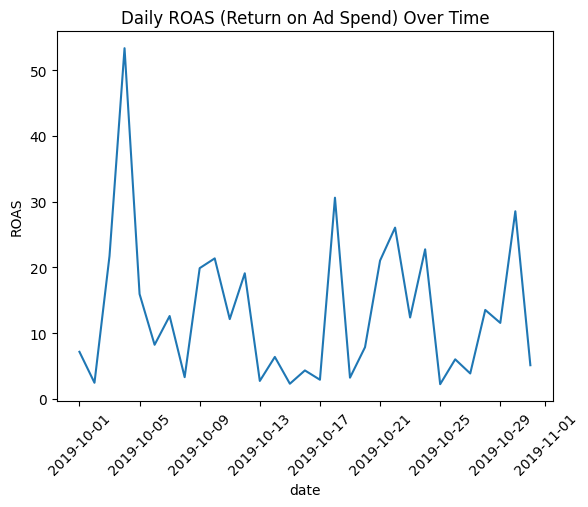

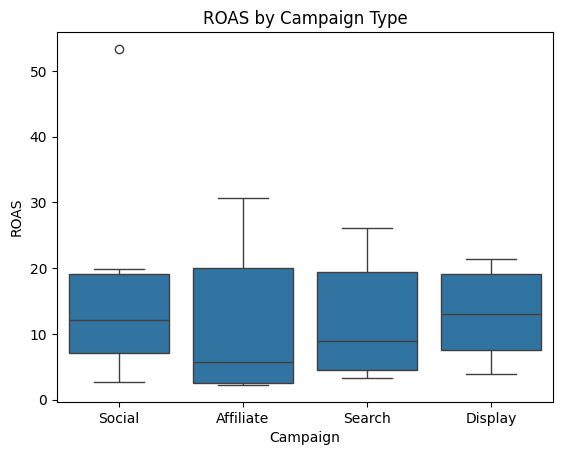

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(x="date", y="ROAS", data=df_daily)
plt.title("Daily ROAS (Return on Ad Spend) Over Time")
plt.xticks(rotation=45)
plt.show()

sns.boxplot(x="Campaign", y="ROAS", data=df_daily)
plt.title("ROAS by Campaign Type")
plt.show()


In [14]:
df_daily.to_csv("data/marketing_kpis.csv", index=False)
# Save the final dataset with marketing KPIs